# Optimization

In [1]:
from watttime.evaluator.evaluator import OptChargeEvaluator
from watttime.evaluator.evaluator import ImpactEvaluator
import pandas as pd
import numpy as np

import tqdm
import numpy as np
import watttime.evaluator.evaluator as wee
import os
username = "jbadolato"
password = "(R)0=2s(z3JZ"
roce = wee.RecalculationOptChargeEvaluator(username,password)
oce = OptChargeEvaluator(username=username,password=password)

## Functions

In [2]:
# 4 seconds per row, mostly API call
def analysis_loop(region, input_dict):
    results = {}
    for key,value in tqdm.tqdm(input_dict.items()):
        value.update({'region':region,'tz_convert':True, "verbose":False})
        df = oce.get_schedule_and_cost_api(**value)
        m, b = np.polyfit(np.arange(len(df.pred_moer.values)),df.pred_moer.values, 1)
        stddev = df.pred_moer.std()
        r = ImpactEvaluator(username,password,df).get_all_emissions_values(region=region)
        r.update({'m':m,'b':b,'stddev':stddev})
        results.update({key:r})
    return results

# 4 seconds per row, mostly API call
def analysis_loop_requery(region, input_dict, interval):
    results = {}
    for key,value in tqdm.tqdm(input_dict.items()):
        value.update(
            {'region':region,
            'tz_convert':True, 
            "optimization_method": "auto", 
            "verbose":False,
            "interval":interval,
            "charge_per_interval":None}
            )
        df = roce.fit_recalculator(**value)
        m, b = np.polyfit(np.arange(len(df.pred_moer.values)),df.pred_moer.values, 1)
        stddev = df.pred_moer.std()
        r = ImpactEvaluator(username,password,df).get_all_emissions_values(region=region)
        r.update({'m':m,'b':b,'stddev':stddev})
        results.update({key:r})
    return results

# 4 seconds per row, mostly API call
def analysis_loop_requery_contiguous(region, input_dict, interval):
    results = {}
    for key,value in tqdm.tqdm(input_dict.items()):
        try:
            value.update(
                {'region':region,
                'tz_convert':True,
                "optimization_method": "auto", 
                "verbose":False,
                "interval":interval,
                "contiguous":True
                }
                )
            df = roce.fit_recalculator(**value).get_combined_schedule()
            m, b = np.polyfit(np.arange(len(df.pred_moer.values)),df.pred_moer.values, 1)
            stddev = df.pred_moer.std()
            r = ImpactEvaluator(username,password,df).get_all_emissions_values(region=region)
            r.update({'m':m,'b':b,'stddev':stddev})
            results.update({key:r})
        except:
            print('error')
            pass
    return results

## Data File

In [ ]:
#df_ev_results["hour"] = df_ev_results.usage_window_start.dt.hour
#df_ev_results["month"] = df_ev_results.usage_window_start.dt.month
#df_ev_results["flex_time"] = df_ev_results["window_length_in_minutes"] - df_ev_results["time_needed"]

In [3]:
df_ev_sample = pd.read_csv("/Users/jen/watttime-python-client/tests/data/data_sample.csv")
#df_ev_sample = pd.read_csv("/Users/jen/watttime-python-client/large_sample.csv")
df_ev_sample["usage_window_start"] = pd.to_datetime(df_ev_sample["usage_window_start"])
df_ev_sample["usage_window_end"] = pd.to_datetime(df_ev_sample["usage_window_end"])
df_ev_sample.rename({"usage_time_required_in_minutes":"time_needed"},axis=1,inplace=True)

In [4]:
df_ev_sample = df_ev_sample[df_ev_sample["early_session_stop"] != True]

In [ ]:
'''
df_ev_sample = df_ev_sample[['usage_window_start',
                    'usage_window_end',
                    'time_needed',
                    'usage_power_kw'
                    ]].sample(1000)
'''

## Results Generation

In [ ]:
%%capture
input_dict = df_ev_sample[['usage_window_start',
                    'usage_window_end',
                    'time_needed',
                    'usage_power_kw'
                    ]].T.to_dict()

In [ ]:
d = df_ev_sample.merge(d,left_index=True,right_index=True)


In [86]:
d["flex_time"] = ((d.usage_window_end - d.usage_window_start) / pd.Timedelta(seconds=60)) - d.time_needed

In [88]:
d["region"] = "PSEI"

In [62]:
# 1000 samples
results = analysis_loop("PSEI",input_dict)

/Users/jen/watttime-python-client/watttime/api.py:727: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  forecast_df.index = pd.to_datetime(forecast_df.index)
/Users/jen/watttime-python-client/watttime/api.py:277: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["point_time"] = pd.to_datetime(df["point_time"])
/Users/jen/watttime-python-client/watttime/api.py:277: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["point_time"] = pd.to_datetime(df["point_time"])
/Users/jen/watttime-python-client/watttime/api.py:727: UserWarning: Could not infer format, so each element will be par

In [ ]:
d = pd.DataFrame.from_dict(results,orient="index")
d["change_in_emissions"] = d["actual"] - d["baseline"]


In [89]:
d.to_csv('/Users/jen/watttime-python-client/tests/data/naive/PSEI_naive_logodds.csv')

In [ ]:
#df_ev_results = df_ev_sample.merge(pd.DataFrame.from_dict(results,orient="index"), left_index=True, right_index=True)

<Axes: ylabel='Frequency'>

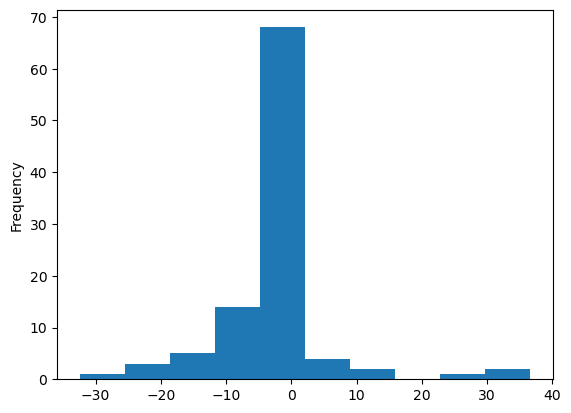

In [ ]:
#df_ev_results.change_in_emissions.plot(kind='hist')

In [ ]:
df_ev_results["hour"] = df_ev_results.usage_window_start.dt.hour
df_ev_results["month"] = df_ev_results.usage_window_start.dt.month
df_ev_results["flex_time"] = df_ev_results["window_length_in_minutes"] - df_ev_results["time_needed"]

# Requery

In [15]:
%%capture
input_dict = df_ev_sample[['usage_window_start',
                    'usage_window_end',
                    'time_needed',
                    'usage_power_kw'
                    ]][90:91].T.to_dict()

In [ ]:
analysis_loop("CAISO_NORTH",input_dict=input_dict,)

{8876: {'usage_window_start': Timestamp('2025-03-20 13:45:00'),
  'usage_window_end': Timestamp('2025-03-20 16:25:00'),
  'time_needed': 40.77508890362057,
  'usage_power_kw': 36.21,
  'region': 'CAISO_NORTH',
  'tz_convert': True,
  'optimization_method': 'auto',
  'verbose': False,
  'interval': 60,
  'charge_per_interval': None}}

In [107]:

results_r_psei = analysis_loop_requery("PSEI",input_dict,interval=15)
df_ev_results_requery = pd.DataFrame.from_dict(results_r_psei,orient="index")
df_ev_results_requery["change_in_emissions"] = df_ev_results_requery["actual"] - df_ev_results_requery["baseline"]
df_ev_results_requery.to_csv("psei_7_results_requery_sample100.csv")

100%|██████████| 10/10 [18:59<00:00, 113.91s/it]


# Analysis

In [ ]:
# https://www.axios.com/2023/11/30/ev-electric-cars-cities-america-most
# ISONE_VT
# PJM_CHICAGO
# CAISO_NORTH
# SPP_TX
# LDPW
# NL (EU)
# PSEI
# SPP_SIOUX

In [145]:
import glob

csv_files = glob.glob(os.path.join('tests/data/raw/', "psei_*.csv"))
dfs = []
for csv in csv_files:
    try:
        df = pd.read_csv(csv, index_col=0)
        # Optionally add filename as a column
        df['source_file'] = os.path.basename(csv)
        dfs.append(df)
    except Exception as e:
        print(f"Error reading {csv}: {str(e)}")
        continue

c = ['forecast', 'actual', 'm', 'b', 'stddev','change_in_emissions']

spp_sioux = pd.concat(dfs)

spp_sioux_naive = pd.read_csv("/Users/jen/watttime-python-client/tests/data/naive/PSEI_naive.csv", index_col=0)
spp = spp_sioux_naive.merge(spp_sioux[c],suffixes=["","_requery15"], left_index=True,right_index=True)
spp.to_csv('tests/data/interim/psei_full.csv')

In [146]:
csv_files = glob.glob(os.path.join('tests/data/interim/', "*.csv"))
dfs = []
for csv in csv_files:
    try:
        df = pd.read_csv(csv, index_col=0)
        # Optionally add filename as a column
        df['source_file'] = os.path.basename(csv)
        dfs.append(df)
    except Exception as e:
        print(f"Error reading {csv}: {str(e)}")
        continue

In [147]:
r = ["PSEI","LDWP","CAISO_NORTH","ISONE_VT","PJM_CHICAGO","SPP_SIOUX","NL","SPP_TX"]
for i,d in enumerate(dfs):
    d["region"] = r[i]

In [149]:
df_full = pd.concat(dfs)
df_full["requery_difference"] = df_full["change_in_emissions_requery15"] -  df_full["change_in_emissions"]

In [150]:
df_full = df_full.reset_index(names=["sample_id"])

In [151]:
df_full = df_full.merge(df_ev_sample, left_on="sample_id", right_index=True, how="left")

In [154]:
df_full.to_csv("tests/data/processed/full_results.csv")

# Results

In [133]:
df_full.groupby("region")["requery_difference"].sum()

region
CAISO_NORTH     -2.974626
ISONE_VT       -21.449540
LDWP            -0.274484
NL             161.646342
PJM_CHICAGO   -179.252184
PSEI            -3.912518
SPP_SIOUX      -82.807472
SPP_TX           3.604553
Name: requery_difference, dtype: float64

## Contiguous charging example

In [17]:
df_ai = df_ev_sample.copy(deep=True)

In [36]:
df_ai["time_needed"] = df_ai["time_needed"].astype(int)
df_ai["charge_per_interval"] = df_ai["time_needed"].apply(lambda x: [int(x*.5),int(x*.5)])
df_ai["contiguous"] = True

In [37]:
in_dict = df_ai.sort_values(by=["flex_time"],ascending=False).head(5)[['usage_window_start',
                    'usage_window_end',
                    'time_needed',
                    'usage_power_kw',
                    'charge_per_interval'
                    ]].T.to_dict()

In [38]:
region = "PJM_CHICAGO"

In [33]:
results_requery = analysis_loop_requery_contiguous(input_dict=in_dict,region=region,interval=15)

  0%|          | 0/5 [00:00<?, ?it/s]

tz converting...


In [34]:
results_requery

{49: {'baseline': 34.29071629166667,
  'forecast': 30.990303637500002,
  'actual': 34.29071629166667,
  'm': -0.35381963642828645,
  'b': 1126.0055629139074,
  'stddev': 103.54047266908192},
 39: {'baseline': 33.96710075,
  'forecast': 32.608386233333334,
  'actual': 32.40808883333334,
  'm': -0.271291446018792,
  'b': 1243.6739373121504,
  'stddev': 25.747172613774243},
 28: {'baseline': 16.864842916666667,
  'forecast': 14.396299408333334,
  'actual': 16.486808250000003,
  'm': -1.4354118683105197,
  'b': 1250.832976561441,
  'stddev': 63.01659118409063},
 53: {'baseline': 16.0622715,
  'forecast': 14.429925691666668,
  'actual': 13.817567416666666,
  'm': -0.6498917533114993,
  'b': 1243.218403361345,
  'stddev': 39.09880837944782},
 83: {'baseline': 45.157782125000004,
  'forecast': 35.05248622083334,
  'actual': 45.22862679166666,
  'm': -1.243649409913467,
  'b': 1201.5392774193556,
  'stddev': 86.61341674438421}}

In [39]:
results = analysis_loop(region,input_dict=in_dict)

100%|██████████| 5/5 [00:31<00:00,  6.20s/it]


In [40]:
pd.DataFrame.from_dict(results,orient="index")

,baseline,forecast,actual,m,b,stddev
49,34.290716,30.990304,34.290716,-0.353820,1126.005563,103.540473
39,33.967101,32.608386,32.408089,-0.271291,1243.673937,25.747173
28,16.864843,14.396299,16.486808,-1.435412,1250.832977,63.016591
53,16.062272,14.429926,13.817567,-0.649892,1243.218403,39.098808
83,45.157782,35.052486,45.228627,-1.243649,1201.539277,86.613417


In [25]:
pd.DataFrame.from_dict(results_requery,orient="index")

,baseline,forecast,actual,m,b,stddev
0,75.619091,74.700767,64.516720,-0.276777,1240.930769,22.318987
1,85.747246,83.494443,83.193899,-0.808309,1260.939860,35.280923
2,41.347542,39.707168,38.237139,-0.396941,1245.463426,17.498060
3,77.547196,70.405485,74.358032,-0.522407,1191.915135,38.646892
4,31.673856,30.250172,31.561067,-2.046635,1243.204521,40.992720


In [129]:
input_dict

{0: {'usage_window_start': Timestamp('2025-02-26 13:55:00'),
  'usage_window_end': Timestamp('2025-02-26 21:30:00'),
  'time_needed': 99,
  'usage_power_kw': 37.9525,
  'charge_per_interval': [49, 49],
  'region': 'CAISO_NORTH',
  'tz_convert': True,
  'verbose': False,
  'optimization_method': 'auto',
  'interval': 15,
  'contiguous': True},
 1: {'usage_window_start': Timestamp('2025-01-30 08:15:00'),
  'usage_window_end': Timestamp('2025-01-30 13:50:00'),
  'time_needed': 175,
  'usage_power_kw': 23.5875,
  'charge_per_interval': [87, 87],
  'region': 'CAISO_NORTH',
  'tz_convert': True,
  'verbose': False,
  'optimization_method': 'auto',
  'interval': 15,
  'contiguous': True},
 2: {'usage_window_start': Timestamp('2025-02-08 09:30:00'),
  'usage_window_end': Timestamp('2025-02-08 17:05:00'),
  'time_needed': 86,
  'usage_power_kw': 22.865,
  'charge_per_interval': [43, 43],
  'region': 'CAISO_NORTH',
  'tz_convert': True,
  'verbose': False,
  'optimization_method': 'auto',
  'int

In [101]:
df_ev_results = df_ev_sample.merge(pd.DataFrame.from_dict(results,orient="index"), left_index=True, right_index=True)
df_ev_results["region"] = region
df_ev_results["change_in_emissions"] = df_ev_results["actual"] - df_ev_results["baseline"]
rr = pd.DataFrame.from_dict(results_requery,orient="index")
rr["change_in_emissions"] = rr["actual"] - rr["baseline"]

In [113]:
df_ev_results = df_ev_results.merge(rr,suffixes=["","_requery15"], left_index=True,right_index=True)

In [114]:
df_ev_results.to_csv(f"tests/data/interim/con/{region}_full.csv")

In [115]:
region

'PSEI'

# Contiguous

In [105]:
import glob

csv_files = glob.glob(os.path.join('tests/data/interim/con/', "*.csv"))
dfs = []
for csv in csv_files:
    try:
        df = pd.read_csv(csv, index_col=0)
        # Optionally add filename as a column
        df['source_file'] = os.path.basename(csv)
        dfs.append(df)
    except Exception as e:
        print(f"Error reading {csv}: {str(e)}")
        continue

In [109]:
len(csv_files) == len(dfs)

True

In [111]:
contiguous_full = pd.concat(dfs)

In [112]:
contiguous_full.to_csv('/Users/jen/watttime-python-client/tests/data/processed/contigous_full_results.csv')

# Analysis

In [ ]:
df_ev_results.groupby('user_type')[["baseline","forecast","actual"]].sum().plot(kind='bar')
df_ev_results["hour"] = df_ev_results.usage_window_start.dt.hour

In [ ]:
df_ev_results.groupby("hour")[["baseline","forecast","actual"]].sum().plot(kind='bar')

In [240]:
full_results

,Unnamed: 0,distinct_dates,user_type,usage_window_start,usage_window_end,initial_charge,time_needed,expected_baseline_charge_complete_timestamp,window_length_in_minutes,final_charge_time,total_capacity,usage_power_kw,total_intervals_plugged_in,MWh_fraction,early_session_stop,hour,month,flex_time
0,204,2025-02-26,r37.9525_tc87_avglc28770_sdlc7739,2025-02-26 13:55:00,2025-02-26 21:30:00,0.226078,99.568540,2025-02-26 15:34:34.112411933,455.0,2025-02-26 15:34:34.112411933,87,37.9525,91.0,0.003163,False,13,2,355.431460
1,112,2025-01-30,r23.587500000000002_tc93_avglc21167_sdlc7163,2025-01-30 08:15:00,2025-01-30 13:50:00,0.207362,175.682814,2025-01-30 11:10:40.968835074,335.0,2025-01-30 11:10:40.968835074,93,23.5875,67.0,0.001966,False,8,1,159.317186
2,93,2025-02-08,r22.865000000000002_tc45_avglc28886_sdlc7099,2025-02-08 09:30:00,2025-02-08 17:05:00,0.217114,86.542423,2025-02-08 10:56:32.545353834,455.0,2025-02-08 10:56:32.545353834,45,22.8650,91.0,0.001905,False,9,2,368.457577
3,163,2025-03-05,r22.567500000000003_tc117_avglc26881_sdlc7014,2025-03-05 16:05:00,2025-03-05 22:15:00,0.425082,163.284447,2025-03-05 18:48:17.066804868,370.0,2025-03-05 18:48:17.066804868,117,22.5675,74.0,0.001881,False,16,3,206.715553
4,186,2025-03-10,r21.76_tc76_avglc23761_sdlc7500,2025-03-10 12:00:00,2025-03-10 15:55:00,0.599220,73.509076,2025-03-10 13:13:30.544573260,235.0,2025-03-10 13:13:30.544573260,76,21.7600,47.0,0.001813,False,12,3,161.490924
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,151,2025-01-22,r22.567500000000003_tc117_avglc26881_sdlc7014,2025-01-22 16:25:00,2025-01-23 01:15:00,0.374226,179.104241,2025-01-22 19:24:06.254438130,530.0,2025-01-22 19:24:06.254438130,117,22.5675,106.0,0.001881,False,16,1,350.895759
96,101,2025-03-09,r22.865000000000002_tc45_avglc28886_sdlc7099,2025-03-09 13:30:00,2025-03-09 23:40:00,0.468398,56.869634,2025-03-09 14:26:52.178012490,610.0,2025-03-09 14:26:52.178012490,45,22.8650,122.0,0.001905,False,13,3,553.130366
97,67,2025-01-22,r28.135_tc88_avglc24456_sdlc7448,2025-01-22 17:50:00,2025-01-22 23:25:00,0.405407,102.201846,2025-01-22 19:32:12.110765742,335.0,2025-01-22 19:32:12.110765742,88,28.1350,67.0,0.002345,False,17,1,232.798154
98,191,2025-01-13,r37.9525_tc87_avglc28770_sdlc7739,2025-01-13 17:05:00,2025-01-14 02:05:00,0.360439,81.088443,2025-01-13 18:26:05.306552364,540.0,2025-01-13 18:26:05.306552364,87,37.9525,108.0,0.003163,False,17,1,458.911557


<Axes: ylabel='Frequency'>

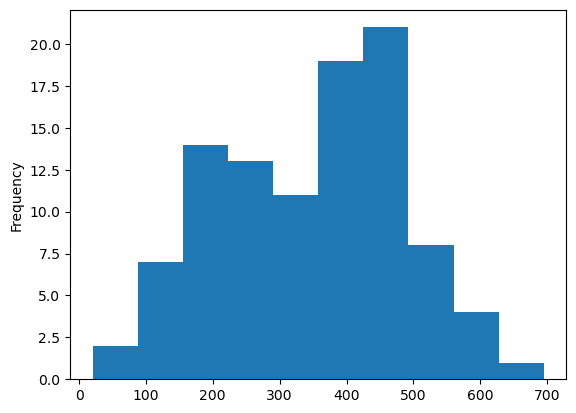

In [242]:
full_results["flex_time"].plot(kind="hist")

In [ ]:
full_results["flex_time"].plot(kind="hist")